# Violence Detection  (Experimentation Notebook)

Binary (violent / non-violent) video classification on RWF-2000. This notebook is for experimentation, visualisation, debugging and analysis; all production logic lives in the `.py` modules and is imported here, never duplicated.

## 1. Project setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/violence_detection"  # edit if you cloned/uploaded elsewhere
    if not os.path.exists(PROJECT_ROOT):
        raise FileNotFoundError(
            "Clone or upload the project to this path first, e.g.:\n"
            "  !git clone <this-repo> /content/violence_detection\n"
            "or edit PROJECT_ROOT above to match where you placed it."
        )
else:
    PROJECT_ROOT = os.path.abspath("")

sys.path.append(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

Project root: /home/pp26/violence_detection/violence_detection


## 2. Imports

In [2]:
import json

import numpy as np
import matplotlib.pyplot as plt
import torch

from config.config import Config, get_default_config
from data.splits import build_sample_lists
from data.dataset import RWFVideoDataset
from data.transforms import ClipTrainTransform, ClipEvalTransform, IMAGENET_MEAN, IMAGENET_STD
from data.dataloaders import build_dataloaders
from models.build import build_model
from training.trainer import Trainer
from training.metrics import compute_binary_metrics
from utils.seed import set_seed
from utils.device import get_device
from utils.model_utils import count_parameters
from utils.checkpoint import load_checkpoint
from inference.predict import ViolenceDetector
from evaluate import run_evaluation

## 3. Configuration

Switch `ARCHITECTURE` between `"lightweight_tsm"` and `"backbone_transformer"` to experiment with either design from a clean, sensible default configuration.

**Note on batch size:** `get_default_config` returns the batch sizes this project was tuned with on a 16GB GPU (32 for `lightweight_tsm`, 8 for `backbone_transformer`). This notebook overrides them to a small value so interactive experimentation is fast and works on any machine, including a CPU-only laptop - depthwise-separable convolutions (used throughout `lightweight_tsm`) are notably memory-hungry in PyTorch's CPU backend (this is a PyTorch/CPU characteristic, not specific to this model - GPU training does not have this issue). Raise `batch_size` back up when running a real training job via `train.py` on the GPU.

In [3]:
ARCHITECTURE = "lightweight_tsm"  # or "backbone_transformer"

config = get_default_config(ARCHITECTURE)
config.data.data_root = "./data/RWF-2000"  
config.training.num_epochs = 25
config.training.batch_size = 32 # number of video clips processed together

config.data.num_workers = 2

print(json.dumps(config.to_dict(), indent=2))

{
  "data": {
    "data_root": "./data/RWF-2000",
    "train_dir": "train",
    "val_dir": "val",
    "class_names": [
      "NonFight",
      "Fight"
    ],
    "num_frames": 16,
    "frame_size": 112,
    "val_ratio": 0.1,
    "num_workers": 2,
    "pin_memory": true
  },
  "model": {
    "architecture": "lightweight_tsm",
    "pretrained": false,
    "freeze_backbone_epochs": 5,
    "d_model": 256,
    "n_heads": 8,
    "n_layers": 4,
    "ff_dim": 1024,
    "transformer_dropout": 0.1,
    "width_mult": 1.0,
    "classifier_dropout": 0.3
  },
  "training": {
    "seed": 42,
    "batch_size": 32,
    "num_epochs": 25,
    "optimizer": "sgd",
    "learning_rate": 0.05,
    "backbone_learning_rate": 1e-05,
    "weight_decay": 5e-05,
    "warmup_ratio": 0.05,
    "grad_clip_norm": 1.0,
    "loss": "bce",
    "focal_gamma": 2.0,
    "focal_alpha": 0.25,
    "mixed_precision": true,
    "early_stopping_patience": 8,
    "monitor_metric": "f1"
  },
  "paths": {
    "experiment_name": "ligh

## 4. Random seeds

In [4]:
set_seed(config.training.seed)
print(f"Seeded Python/NumPy/PyTorch with seed={config.training.seed}")

Seeded Python/NumPy/PyTorch with seed=42


## 5. Dataset inspection

In [5]:
train_samples, val_samples, test_samples = build_sample_lists(config.data, config.training.seed)
print(f"train: {len(train_samples)}  val: {len(val_samples)}  test: {len(test_samples)}")

train: 1440  val: 160  test: 400


## 6. Exploratory data analysis

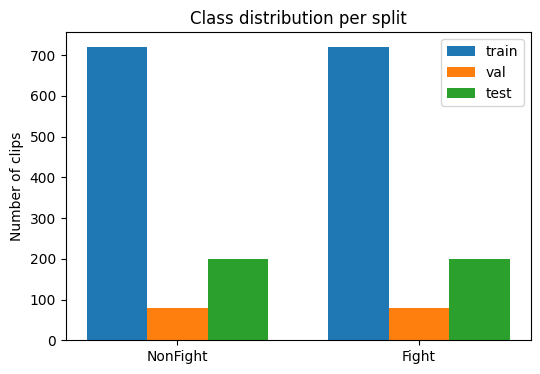

In [6]:
def class_counts(samples):
    counts = [0, 0]
    for _, label in samples:
        counts[label] += 1
    return counts

splits = {"train": train_samples, "val": val_samples, "test": test_samples}
fig, ax = plt.subplots(figsize=(6, 4))
width = 0.25
for i, (name, samples) in enumerate(splits.items()):
    counts = class_counts(samples)
    ax.bar(np.arange(2) + i * width, counts, width=width, label=name)
ax.set_xticks(np.arange(2) + width)
ax.set_xticklabels(config.data.class_names)
ax.set_ylabel("Number of clips")
ax.set_title("Class distribution per split")
ax.legend()
plt.show()

## 7. Data preprocessing

In [7]:
train_transform = ClipTrainTransform(config.data.frame_size)
eval_transform = ClipEvalTransform(config.data.frame_size)
print("Train transform resize/crop size:", config.data.frame_size)

Train transform resize/crop size: 112


## 8. Sample visualization

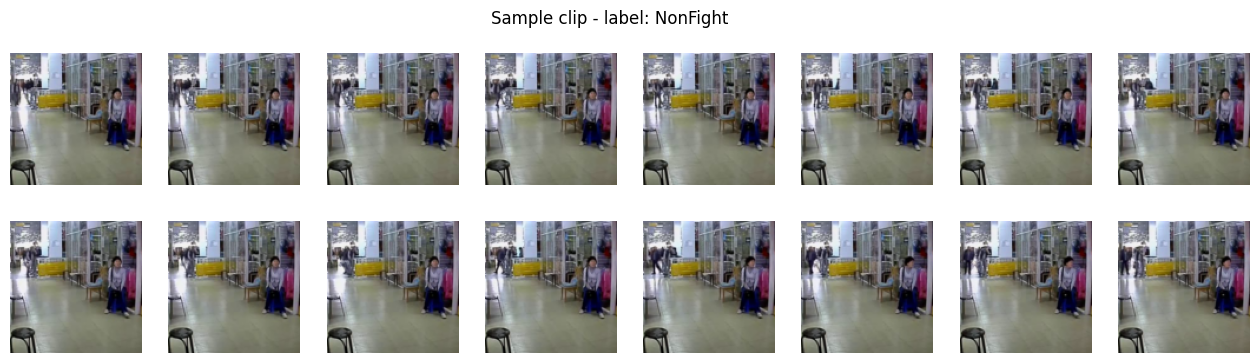

In [8]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

preview_dataset = RWFVideoDataset([train_samples[0]], config.data.num_frames, eval_transform, train=False)
clip_tensor, label = preview_dataset[0]

n_cols = min(8, config.data.num_frames)
n_rows = max(1, config.data.num_frames // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
for i, ax in enumerate(np.array(axes).flat):
    frame = (clip_tensor[i] * std + mean).clamp(0, 1)
    ax.imshow(frame.permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle(f"Sample clip - label: {config.data.class_names[int(label)]}")
plt.show()

## 9. Dataset and DataLoader creation

In [9]:
train_loader, val_loader, test_loader = build_dataloaders(config)
clips, labels = next(iter(train_loader))
print("Batch clip shape:", clips.shape, "| labels shape:", labels.shape)

Batch clip shape: torch.Size([32, 16, 3, 112, 112]) | labels shape: torch.Size([32])


## 10. Model definition / import

In [10]:
model = build_model(config)
print(model.__class__.__name__)

LightweightTSMNet


## 11. Model summary

In [11]:
total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(model)

Total parameters: 1,924,287
Trainable parameters: 1,924,287
LightweightTSMNet(
  (stem): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (stages): Sequential(
    (0): InvertedResidualBlock(
      (temporal_shift): TemporalShift()
      (expand_and_depthwise): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (se): Identity()
      (project): Sequential(
        (0): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): InvertedResidualBlock(
      (temporal_shift): TemporalShift()
      (expa

## 12. Training

In [12]:
device = get_device()
print("Training on:", device)

trainer = Trainer(model, train_loader, val_loader, config, device)
trainer.fit()

Training on: cuda


Epoch 1/25 | train_loss=0.6937 val_loss=0.6937 val_f1=0.6667 val_auc=0.5000 time=161.7s


Epoch 2/25 | train_loss=0.6868 val_loss=1.1688 val_f1=0.0471 val_auc=0.6111 time=149.5s


Epoch 3/25 | train_loss=0.6602 val_loss=0.6519 val_f1=0.6410 val_auc=0.7017 time=151.6s


Epoch 4/25 | train_loss=0.6160 val_loss=0.7644 val_f1=0.3889 val_auc=0.6896 time=152.6s


...

Epoch 21/25 | train_loss=0.3640 val_loss=0.3079 val_f1=0.8848 val_auc=0.9455 time=151.2s


Epoch 22/25 | train_loss=0.3526 val_loss=0.3387 val_f1=0.8837 val_auc=0.9495 time=151.8s


Epoch 23/25 | train_loss=0.3424 val_loss=0.3202 val_f1=0.8743 val_auc=0.9464 time=149.6s


Epoch 24/25 | train_loss=0.3459 val_loss=0.3191 val_f1=0.8743 val_auc=0.9454 time=148.0s


Epoch 25/25 | train_loss=0.3419 val_loss=0.3335 val_f1=0.8889 val_auc=0.9441 time=151.3s


## 13. Training curves

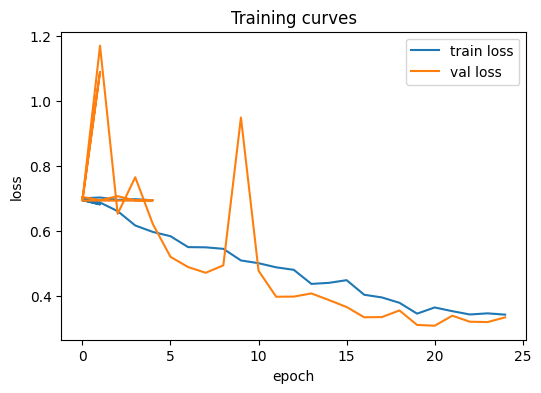

In [13]:
history_path = f"{config.paths.log_dir}/{config.paths.experiment_name}/history.jsonl"
with open(history_path) as history_file:
    records = [json.loads(line) for line in history_file]

epochs = [r["epoch"] for r in records]
train_losses = [r["train_loss"] for r in records]
val_losses = [r["val_loss"] for r in records]

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, label="train loss")
plt.plot(epochs, val_losses, label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Training curves")
plt.show()

## 14. Validation results

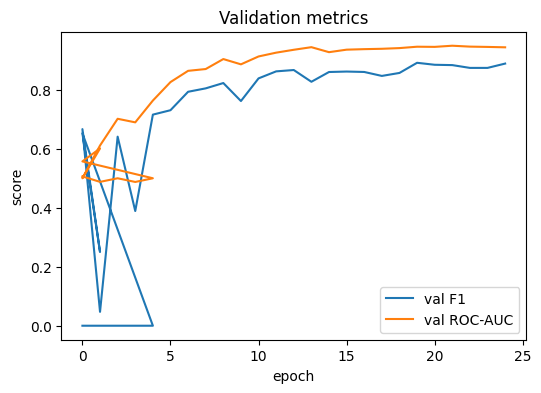

In [14]:
val_f1s = [r["val_f1"] for r in records]
val_aucs = [r["val_roc_auc"] for r in records]

plt.figure(figsize=(6, 4))
plt.plot(epochs, val_f1s, label="val F1")
plt.plot(epochs, val_aucs, label="val ROC-AUC")
plt.xlabel("epoch"); plt.ylabel("score"); plt.legend(); plt.title("Validation metrics")
plt.show()

## 15. Error analysis

Runs the current model over the validation split one clip at a time (rather than in shuffled batches) so each prediction can be traced back to its source file. For a large validation set, slice `val_samples[:200]` first to keep this quick.

In [15]:
val_dataset_named = RWFVideoDataset(val_samples, config.data.num_frames, eval_transform, train=False)
model.eval()
results = []
with torch.no_grad():
    for i in range(len(val_dataset_named)):
        clip, _ = val_dataset_named[i]
        probability = torch.sigmoid(model(clip.unsqueeze(0).to(device))).item()
        path, true_label = val_samples[i]
        results.append({"path": path, "label": true_label, "probability": probability})

misclassified = [r for r in results if (r["probability"] >= 0.5) != bool(r["label"])]
misclassified.sort(key=lambda r: abs(r["probability"] - r["label"]), reverse=True)
print(f"{len(misclassified)} / {len(results)} validation clips misclassified")
for r in misclassified[:5]:
    print(r)

19 / 160 validation clips misclassified
{'path': 'data/RWF-2000/train/NonFight/video_0632.avi', 'label': 0, 'probability': 0.9831870794296265}
{'path': 'data/RWF-2000/train/NonFight/video_0014.avi', 'label': 0, 'probability': 0.9782570600509644}
{'path': 'data/RWF-2000/train/NonFight/video_0613.avi', 'label': 0, 'probability': 0.9551249146461487}
{'path': 'data/RWF-2000/train/NonFight/video_0302.avi', 'label': 0, 'probability': 0.9542718529701233}
{'path': 'data/RWF-2000/train/Fight/video_0101.avi', 'label': 1, 'probability': 0.09440560638904572}


## 16. Final evaluation

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 13/13 [00:38<00:00,  2.97s/it]

{
  "accuracy": 0.8025,
  "precision": 0.8040201005025126,
  "recall": 0.8,
  "f1": 0.8020050125313283,
  "roc_auc": 0.88495
}


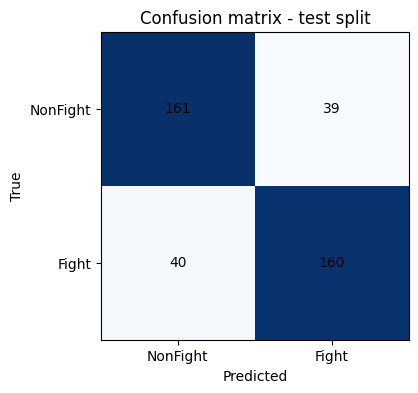

In [16]:
test_metrics = run_evaluation(model, test_loader, device)
print(json.dumps({k: v for k, v in test_metrics.items() if k != "confusion_matrix"}, indent=2))

cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha="center", va="center")
ax.set_xticks([0, 1]); ax.set_xticklabels(config.data.class_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(config.data.class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix - test split")
plt.show()

## 17. Example predictions

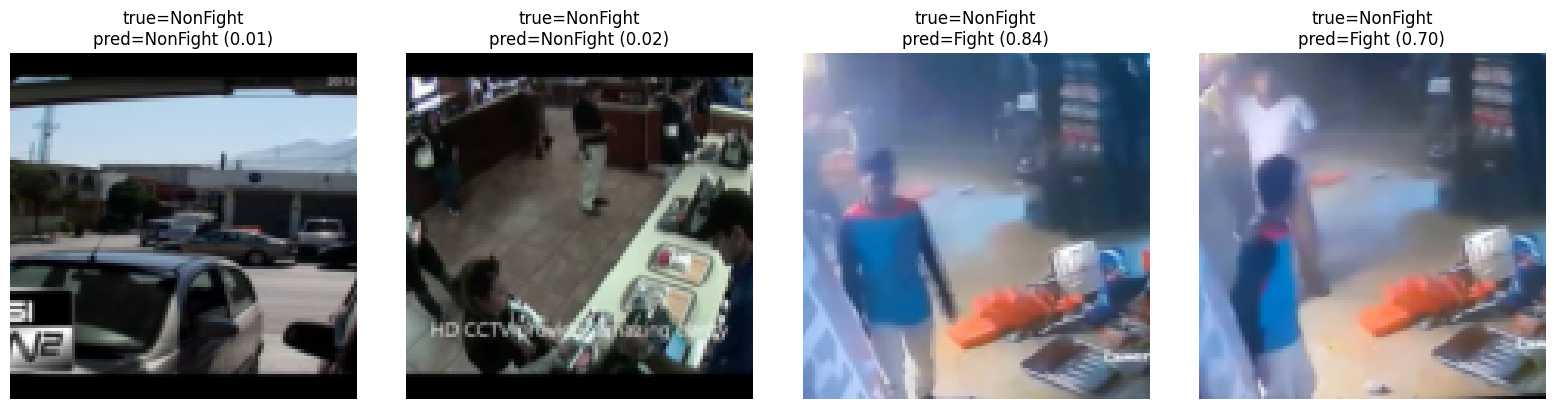

In [17]:
n_examples = min(4, len(test_samples))
fig, axes = plt.subplots(1, n_examples, figsize=(4 * n_examples, 4))
for ax, (path, true_label) in zip(np.array(axes).flat, test_samples[:n_examples]):
    single = RWFVideoDataset([(path, true_label)], config.data.num_frames, eval_transform, train=False)
    clip, _ = single[0]
    with torch.no_grad():
        probability = torch.sigmoid(model(clip.unsqueeze(0).to(device))).item()
    middle_frame = (clip[len(clip) // 2] * std + mean).clamp(0, 1)
    ax.imshow(middle_frame.permute(1, 2, 0).numpy())
    predicted = config.data.class_names[int(probability >= 0.5)]
    ax.set_title(f"true={config.data.class_names[true_label]}\npred={predicted} ({probability:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 18. Model checkpoint loading

In [18]:
best_checkpoint_path = f"{config.paths.checkpoint_dir}/{config.paths.experiment_name}/best.pt"
reloaded_model = build_model(config).to(device)
checkpoint_info = load_checkpoint(best_checkpoint_path, reloaded_model, map_location=device)
print("Loaded checkpoint from epoch:", checkpoint_info["epoch"], "| best_metric:", checkpoint_info["best_metric"])

Loaded checkpoint from epoch: 19 | best_metric: 0.891566265060241


## 19. Inference examples

In [19]:
detector = ViolenceDetector(best_checkpoint_path, device=device)
example_path, example_label = test_samples[0]
prediction = detector.predict(example_path)
print("Ground truth:", config.data.class_names[example_label])
print("Prediction:", prediction)

Ground truth: NonFight
Prediction: {'label': 'NonFight', 'probability': 0.01356088649481535, 'threshold': 0.5}


## 20. Conclusions

_Summarise your findings here once you have real training runs to compare, e.g.:_

- Final test accuracy / F1 / ROC-AUC for each architecture.
- Which architecture trained faster and which reached a higher ceiling.
- Recurring patterns in the misclassified clips from §15 (lighting, crowd density, camera motion, ...).
- Next steps: more augmentation, a different frame count, ensembling both architectures, etc.